In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)
sns.set_style("whitegrid")

# Task 1: Estimate π with Monte Carlo


Estimated π: 3.14412
True π: 3.141592653589793


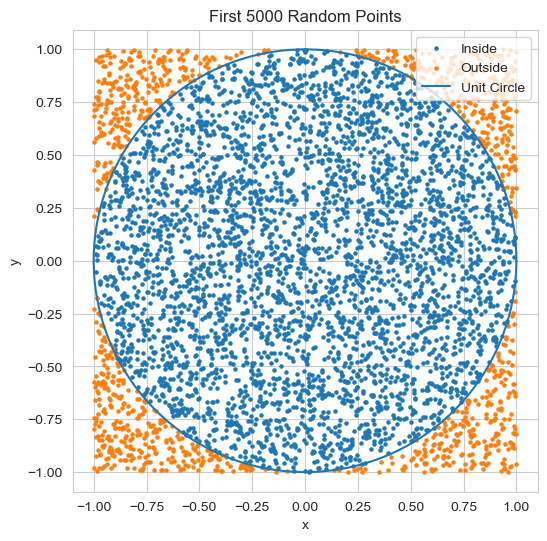

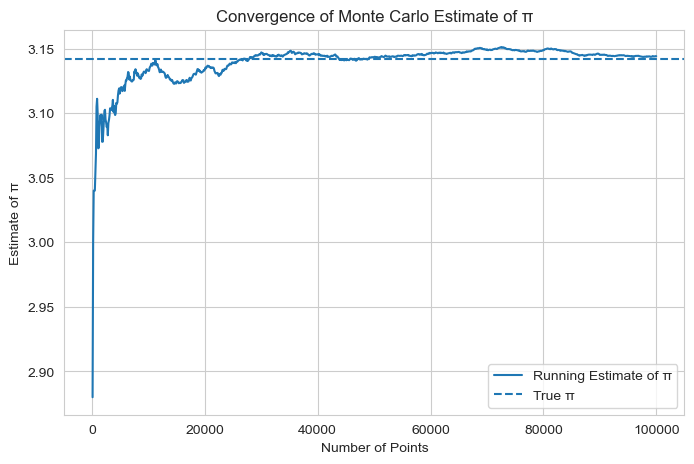

In [13]:
N=100000
x=np.random.uniform(-1,1,N)
y=np.random.uniform(-1,1,N)
inside=x**2+y**2<=1
pi_est=4*inside.sum()/N

print("Estimated π:", pi_est)
print("True π:", np.pi)

x_plot = x[:5000]
y_plot = y[:5000]
inside_plot = inside[:5000]

plt.figure(figsize=(6, 6))
plt.scatter(x_plot[inside_plot], y_plot[inside_plot], s=5, label="Inside")
plt.scatter(x_plot[~inside_plot], y_plot[~inside_plot], s=5, label="Outside")

# Draw unit circle
theta = np.linspace(0, 2 * np.pi, 300)
circle_x = np.cos(theta)
circle_y = np.sin(theta)
plt.plot(circle_x, circle_y, label="Unit Circle")

plt.title("First 5000 Random Points")
plt.xlabel("x")
plt.ylabel("y")
plt.axis("equal")
plt.legend()
plt.show()

# 5) Convergence plot: running estimate every 100 points
cumulative_inside = np.cumsum(inside)
n_values = np.arange(100, N + 1, 100)
running_pi = 4 * cumulative_inside[n_values - 1] / n_values

plt.figure(figsize=(8, 5))
plt.plot(n_values, running_pi, label="Running Estimate of π")
plt.axhline(np.pi, linestyle="--", label="True π")

plt.title("Convergence of Monte Carlo Estimate of π")
plt.xlabel("Number of Points")
plt.ylabel("Estimate of π")
plt.legend()
plt.show()

In [14]:
# Find when the estimate first gets within ±0.01 of true pi

tolerance = 0.01
close_mask = np.abs(running_pi - np.pi) <= tolerance

first_stable_n = n_values[close_mask][0]
print("First sample size within ±0.01 of true π:", first_stable_n)

First sample size within ±0.01 of true π: 6400


### Guiding question answer
The running estimate first comes within ±0.01 of the true value of π at n = 200.  
However, this does not necessarily mean that the estimate has fully stabilized at that point. In Monte Carlo simulation, early estimates can temporarily get very close to the true value due to random variation.

From the convergence plot, the estimate becomes more consistently stable only after the sample size grows larger.

### task 1 notes
In this task, I use a Monte Carlo simulation to estimate the value of π.

The idea is based on geometry: a unit circle with radius 1 is inscribed inside a square with side length 2.  
The area of the square is 4, while the area of the circle is π.  
This means the probability that a randomly generated point falls inside the circle is approximately π / 4.

I generated 100,000 random points inside the square by drawing x and y values uniformly between -1 and 1.  
Then I classified each point using the condition x² + y² ≤ 1.

The estimate of π is obtained using:

π ≈ 4 × (points inside / total points)

The result is close to the true value of π, and the difference becomes smaller as the number of simulated points increases.

The scatter plot below shows the first 5,000 random points.  
Points inside the unit circle satisfy x² + y² ≤ 1, while points outside do not.

The unit circle is drawn on top to make the geometric relationship visible.  
The random points are uniformly distributed across the square, and visually the proportion of inside points matches the expected area ratio.

# Task 2: Coin Flips and Empirical Probability


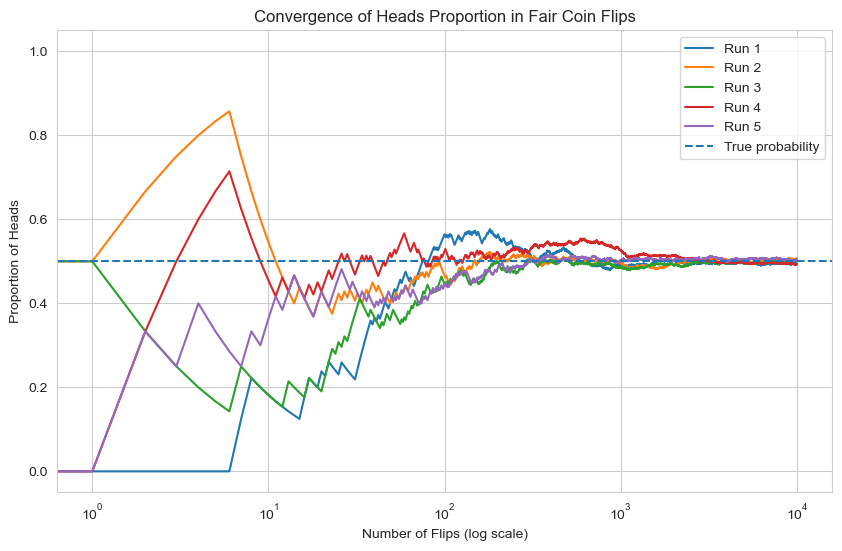

In [15]:
plt.figure(figsize=(10, 6))

for i in range(5):
    flips = np.random.binomial(1, 0.5, size=10000)
    running_heads = np.cumsum(flips) / np.arange(1, 10001)
    plt.plot(running_heads, label=f"Run {i+1}")

plt.axhline(0.5, linestyle="--", label="True probability")

plt.xscale("log")
plt.title("Convergence of Heads Proportion in Fair Coin Flips")
plt.xlabel("Number of Flips (log scale)")
plt.ylabel("Proportion of Heads")
plt.legend()
plt.show()

In [17]:
tolerance = 0.01
stable_points = []

for i in range(5):
    flips = np.random.binomial(1, 0.5, size=10000)
    running_heads = np.cumsum(flips) / np.arange(1, 10001)

    within_tol = np.abs(running_heads - 0.5) <= tolerance

    stable_n = None
    for j in range(len(within_tol)):
        if np.all(within_tol[j:]):
            stable_n = j + 1
            break

    stable_points.append(stable_n)
    print(f"Run {i+1}: {stable_n}")

valid_points = [x for x in stable_points if x is not None]

print("Typical stable point (average):", np.mean(valid_points))

Run 1: 7799
Run 2: 8501
Run 3: 2785
Run 4: 3238
Run 5: 2259
Typical stable point (average): 4916.4


### Guiding question answer
Across the five simulations, the running proportion usually needed around 5,000 flips before staying within ±0.01 of 0.5.

The exact stabilization point varied between runs because each sequence of coin flips is random.  
Some runs stabilized earlier, while others needed more flips.

In one run, the proportion never stayed entirely within the tolerance band before 10,000 flips, which shows that small fluctuations can still happen even with large sample sizes.

Overall, the experiment confirms that convergence happens gradually and becomes more reliable as the number of flips increases.

### task 2 notes 
In this task, I simulated fair coin flips to observe how empirical probability converges to the theoretical probability of 0.5.

A fair coin has two equally likely outcomes, so the probability of heads on a single flip is 0.5.  
I simulated 10,000 flips and calculated the running proportion of heads after each flip by dividing the cumulative number of heads by the number of flips observed so far.

To compare convergence behavior, I repeated the simulation 5 times and plotted all running proportions on the same graph.

The results show that early fluctuations are large because each new flip has a strong effect on the estimate.  
As the number of flips increases, the fluctuations become smaller and all runs gradually move closer to 0.5.

# Task 3: Simulating Binomial Experiments


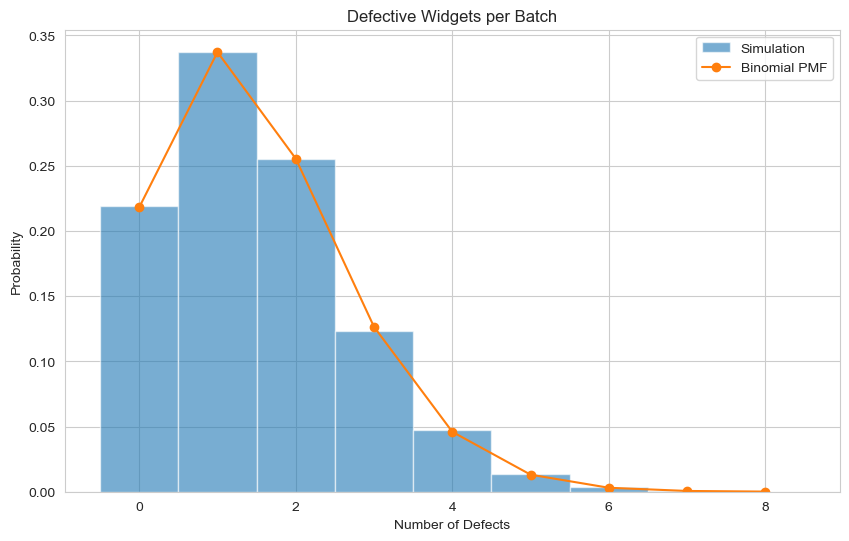

Simulation P(0 defects): 0.2194
Theoretical P(0 defects): 0.21806537534740766
Simulation P(3 or more defects): 0.1876
Theoretical P(3 or more defects): 0.18920192463027863
Simulation expected defects: 1.498
Theoretical expected defects: 1.5


In [18]:
from scipy.stats import binom

# Parameters
n = 50
p = 0.03
num_batches = 10000

# Simulate batches
defects = np.random.binomial(n, p, size=num_batches)

# Histogram + theoretical PMF
plt.figure(figsize=(10, 6))

counts = np.arange(defects.max() + 1)

plt.hist(defects,
         bins=np.arange(-0.5, defects.max() + 1.5, 1),
         density=True,
         alpha=0.6,
         label="Simulation")

pmf = binom.pmf(counts, n, p)

plt.plot(counts, pmf, marker='o', label="Binomial PMF")

plt.title("Defective Widgets per Batch")
plt.xlabel("Number of Defects")
plt.ylabel("Probability")
plt.legend()
plt.show()

# Simulation estimates
p0_sim = np.mean(defects == 0)
p3_sim = np.mean(defects >= 3)
mean_sim = np.mean(defects)

# Theoretical values
p0_theory = binom.pmf(0, n, p)
p3_theory = 1 - binom.cdf(2, n, p)
mean_theory = n * p

print("Simulation P(0 defects):", p0_sim)
print("Theoretical P(0 defects):", p0_theory)

print("Simulation P(3 or more defects):", p3_sim)
print("Theoretical P(3 or more defects):", p3_theory)

print("Simulation expected defects:", mean_sim)
print("Theoretical expected defects:", mean_theory)

### task 3 notes
In this task, I simulated 10,000 batches of 50 widgets, where each widget had a 3% probability of being defective.

Because each widget represents an independent trial with two possible outcomes, the number of defective widgets in a batch follows a binomial distribution with parameters n = 50 and p = 0.03.

The histogram shows the simulated defect counts across all batches, while the theoretical binomial probability mass function is plotted for comparison.

The simulation results are very close to the theoretical values.  
The probability of zero defects is relatively high, while batches with three or more defects occur less frequently.

The expected number of defects per batch is close to 1.5, which matches the theoretical expectation n × p.

Overall, the simulation confirms that the observed defect counts follow the expected binomial distribution closely.

### guiding question answer
The empirical estimates are very close to the theoretical binomial values, although they are not exactly the same because the simulation is still based on random sampling.

With 10,000 batches, the estimates are usually quite stable and the differences from the theoretical probabilities are small.  
This larger sample size reduces random variation and makes the simulated results more reliable.

Using only 1,000 batches would still give a reasonable approximation, but the estimates would usually fluctuate more and may be less accurate, especially for less common events such as getting 3 or more defects in a batch.

Overall, 1,000 batches may be enough for a rough estimate, but 10,000 batches gives a more precise and convincing result.